<a href="https://colab.research.google.com/github/lauravazqx/Temas-Selectos-de-Analisis-Numerico/blob/main/Proyecto_4_TSAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto 4.
# Temas Selectos de Aálisis Numérico
## Solución Numérica de Ecuaciones Difrenciales Ordinarias.
### Elaborado por: Salvador Vazquez Laura Teresa.
#### Ejercicios Computacionales:

### 17. Programar los métodos.
a) Euler

b) Runge-Kutta Segundo Orden

c) Euler Modificado

d) Runge-Kutta Cuarto Orden

e) Adams-Bashforth

f) Adams-Moulton

In [1]:
# Respuesta para la pregunta 17.

import numpy as np

# a) Método de Euler
def euler(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for i in range(n):
        x_new = x[-1] + h * f(t[-1], x[-1])
        t.append(t[-1] + h)
        x.append(x_new)
    return t, x

# b) Método de Euler Modificado (Heun)
def euler_modificado(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for i in range(n):
        x_predict = x[-1] + h * f(t[-1], x[-1])
        x_new = x[-1] + (h/2) * (f(t[-1], x[-1]) + f(t[-1] + h, x_predict))
        t.append(t[-1] + h)
        x.append(x_new)
    return t, x

# c) Método de Runge-Kutta de Segundo Orden
def runge_kutta2(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for i in range(n):
        k1 = f(t[-1], x[-1])
        k2 = f(t[-1] + h, x[-1] + h * k1)
        x_new = x[-1] + (h/2) * (k1 + k2)
        t.append(t[-1] + h)
        x.append(x_new)
    return t, x

# d) Método de Runge-Kutta de Cuarto Orden
def runge_kutta4(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for i in range(n):
        k1 = f(t[-1], x[-1])
        k2 = f(t[-1] + h/2, x[-1] + h/2 * k1)
        k3 = f(t[-1] + h/2, x[-1] + h/2 * k2)
        k4 = f(t[-1] + h, x[-1] + h * k3)
        x_new = x[-1] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t.append(t[-1] + h)
        x.append(x_new)
    return t, x

# e) Método de Adams-Bashforth de 2 pasos
def adams_bashforth2(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    # Obtener segundo punto con RK4
    t1 = t0 + h
    x1 = x0 + (h/6) * (
        f(t0, x0) +
        2*f(t0 + h/2, x0 + h/2 * f(t0, x0)) +
        2*f(t0 + h/2, x0 + h/2 * f(t0 + h/2, x0 + h/2 * f(t0, x0))) +
        f(t0 + h, x0 + h * f(t0 + h/2, x0 + h/2 * f(t0 + h/2, x0 + h/2 * f(t0, x0))))
    )
    t.append(t1)
    x.append(x1)

    for i in range(1, n):
        t_new = t[-1] + h
        x_new = x[-1] + h/2 * (3*f(t[-1], x[-1]) - f(t[-2], x[-2]))
        t.append(t_new)
        x.append(x_new)
    return t, x

# f) Método de Adams-Moulton de 2 pasos (predictor-corrector)
def adams_moulton2(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    # Obtener segundo punto con RK4
    t1 = t0 + h
    x1 = x0 + (h/6) * (
        f(t0, x0) +
        2*f(t0 + h/2, x0 + h/2 * f(t0, x0)) +
        2*f(t0 + h/2, x0 + h/2 * f(t0 + h/2, x0 + h/2 * f(t0, x0))) +
        f(t0 + h, x0 + h * f(t0 + h/2, x0 + h/2 * f(t0 + h/2, x0 + h/2 * f(t0, x0))))
    )
    t.append(t1)
    x.append(x1)

    for i in range(1, n):
        t_new = t[-1] + h
        # Predictor (Adams-Bashforth)
        x_pred = x[-1] + h/2 * (3*f(t[-1], x[-1]) - f(t[-2], x[-2]))
        # Corrector (Adams-Moulton)
        x_new = x[-1] + h/2 * (f(t_new, x_pred) + f(t[-1], x[-1]))
        t.append(t_new)
        x.append(x_new)
    return t, x


### 18. Dada la EDO
$
\left\{
\begin{array}{ll}
x'= e^{xt}+cos(x-t) \\
x(1) = 3
\end{array}
\right.
$

con $h = 0.01$, resolver usando:

(a) Método de Euler.  
(b) Método de Euler Modificado.

Graficar resultados y comparar ambos métodos.

<ipython-input-2-1d11f2685531>:7: RuntimeWarning: overflow encountered in exp
  return np.exp(x * t) + np.cos(x - t)
<ipython-input-2-1d11f2685531>:7: RuntimeWarning: invalid value encountered in cos
  return np.exp(x * t) + np.cos(x - t)


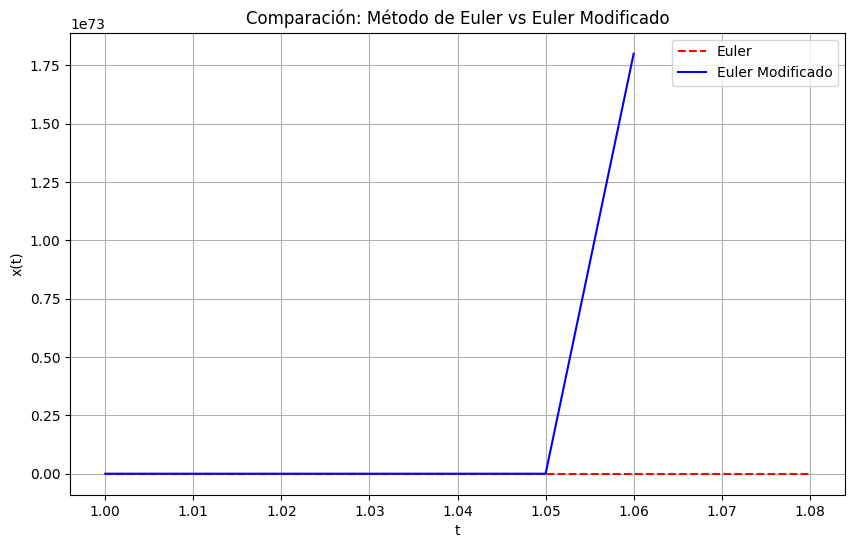

In [2]:
# Respuesta para la pregunta 18.
import numpy as np
import matplotlib.pyplot as plt

# Definimos la función f(t, x) de la EDO
def f(t, x):
    return np.exp(x * t) + np.cos(x - t)

# Método de Euler
def euler(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for i in range(n):
        x_new = x[-1] + h * f(t[-1], x[-1])
        t.append(t[-1] + h)
        x.append(x_new)
    return np.array(t), np.array(x)

# Método de Euler Modificado (Heun)
def euler_modificado(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for i in range(n):
        x_predict = x[-1] + h * f(t[-1], x[-1])
        x_new = x[-1] + (h/2) * (f(t[-1], x[-1]) + f(t[-1] + h, x_predict))
        t.append(t[-1] + h)
        x.append(x_new)
    return np.array(t), np.array(x)

# Condiciones iniciales
t0 = 1
x0 = 3
h = 0.01
n = int((2 - t0) / h)  # Hasta t = 2

# Resolver con ambos métodos
t_euler, x_euler = euler(f, t0, x0, h, n)
t_heun, x_heun = euler_modificado(f, t0, x0, h, n)

# Graficar resultados
plt.figure(figsize=(10, 6))
plt.plot(t_euler, x_euler, label='Euler', linestyle='--', color='red')
plt.plot(t_heun, x_heun, label='Euler Modificado', linestyle='-', color='blue')
plt.title("Comparación: Método de Euler vs Euler Modificado")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()


### El método de Euler Modificado es más preciso, ya que usa una correción con la pendiente al final del intervalo analizado.

### 19. Dada la siguiente EDO:

$
\left\{
\begin{array}{ll}
x'= - \frac{3t^2x+x^2}{2t^3+3tx} \\
x(1) = -2
\end{array}
\right.
$

resolver usando series de Taylor con orden 2 y orden 3 en su aproximación. Tomando $h=-0.01$ y $t \in [0,1]$

Graficar resultados y comparar ambos métodos.

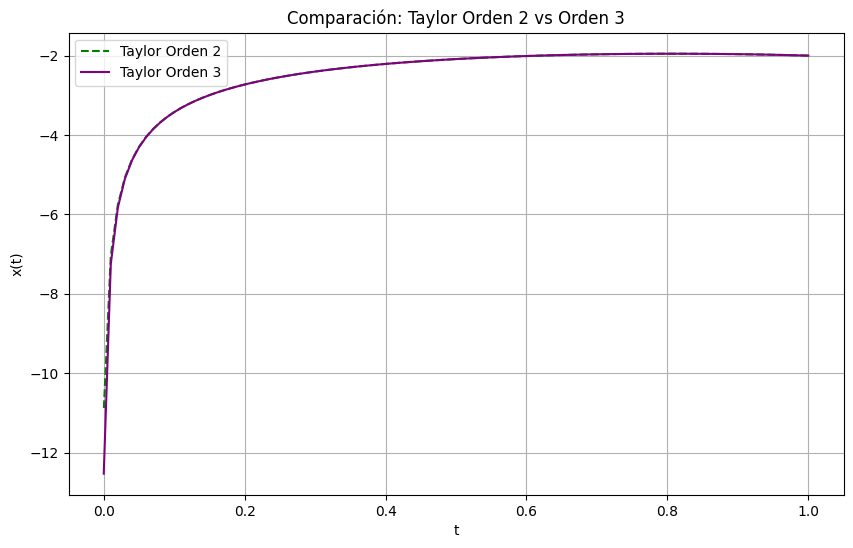

In [3]:
# Solución para la pregunta 19.

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Variables simbólicas
t_sym, x_sym = sp.symbols('t x')
f_sym = - (3*t_sym**2 * x_sym + x_sym**2) / (2*t_sym**3 + 3*t_sym*x_sym)

# Derivadas simbólicas para Taylor de orden 3
f_t = sp.diff(f_sym, t_sym)
f_x = sp.diff(f_sym, x_sym)

# Para orden 3: derivada de x''(t)
x_prime = f_sym
x_double_prime = f_t + f_x * f_sym
f_tt = sp.diff(f_t, t_sym)
f_tx = sp.diff(f_t, x_sym)
f_xx = sp.diff(f_x, x_sym)

x_triple_prime = f_tt + 2*f_tx*f_sym + f_xx*(f_sym**2) + f_x*(f_t + f_x*f_sym)

# Convertimos a funciones numéricas
f = sp.lambdify((t_sym, x_sym), f_sym, 'numpy')
f1 = sp.lambdify((t_sym, x_sym), x_double_prime, 'numpy')
f2 = sp.lambdify((t_sym, x_sym), x_triple_prime, 'numpy')

# Método de Taylor orden 2
def taylor_order2(f, f1, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for _ in range(n):
        t_new = t[-1] + h
        x_new = x[-1] + h*f(t[-1], x[-1]) + (h**2/2)*f1(t[-1], x[-1])
        t.append(t_new)
        x.append(x_new)
    return np.array(t), np.array(x)

# Método de Taylor orden 3
def taylor_order3(f, f1, f2, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for _ in range(n):
        t_new = t[-1] + h
        x_new = x[-1] + h*f(t[-1], x[-1]) + (h**2/2)*f1(t[-1], x[-1]) + (h**3/6)*f2(t[-1], x[-1])
        t.append(t_new)
        x.append(x_new)
    return np.array(t), np.array(x)

# Condiciones iniciales
t0 = 1
x0 = -2
h = -0.01
n = int((0 - t0)/h)

# Ejecutar métodos
t2, x2 = taylor_order2(f, f1, t0, x0, h, n)
t3, x3 = taylor_order3(f, f1, f2, t0, x0, h, n)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(t2, x2, label='Taylor Orden 2', linestyle='--', color='green')
plt.plot(t3, x3, label='Taylor Orden 3', linestyle='-', color='purple')
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Comparación: Taylor Orden 2 vs Orden 3")
plt.legend()
plt.grid(True)
plt.show()




### El método de Taylor de orden 3 es más preciso, especialmente en problemas no lineales o con comportamiento complejo.

### 20. Dada la EDO:
$
\left\{
\begin{array}{ll}
x'= -2tx^2; \\
x(0) = 1
\end{array}
\right.
$

con solución: $x(t)= \frac{1}{1+t^2}$

Resolver por:

a) Runge-Kutta 2° orden

b) Runge-Kutta 4° orden

Comparar y graficar resultados con la solución exacta.

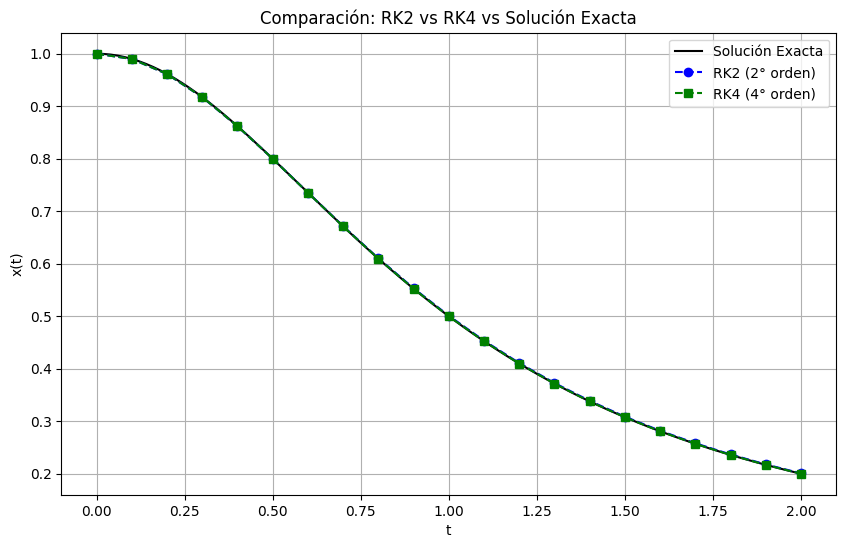

In [4]:
# Solución para la pregunta 20.

import numpy as np
import matplotlib.pyplot as plt

# Definición de la EDO
def f(t, x):
    return -2 * t * x**2

# Solución exacta
def exact_solution(t):
    return 1 / (1 + t**2)

# Runge-Kutta de segundo orden (RK2)
def rk2(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for _ in range(n):
        t_k = t[-1]
        x_k = x[-1]
        k1 = f(t_k, x_k)
        k2 = f(t_k + h, x_k + h * k1)
        x_k1 = x_k + (h/2) * (k1 + k2)
        t.append(t_k + h)
        x.append(x_k1)
    return np.array(t), np.array(x)

# Runge-Kutta de cuarto orden (RK4)
def rk4(f, t0, x0, h, n):
    t = [t0]
    x = [x0]
    for _ in range(n):
        t_k = t[-1]
        x_k = x[-1]
        k1 = f(t_k, x_k)
        k2 = f(t_k + h/2, x_k + h/2 * k1)
        k3 = f(t_k + h/2, x_k + h/2 * k2)
        k4 = f(t_k + h, x_k + h * k3)
        x_k1 = x_k + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        t.append(t_k + h)
        x.append(x_k1)
    return np.array(t), np.array(x)

# Parámetros
t0 = 0
x0 = 1
h = 0.1
t_end = 2
n = int((t_end - t0)/h)

# Ejecutar métodos
t_rk2, x_rk2 = rk2(f, t0, x0, h, n)
t_rk4, x_rk4 = rk4(f, t0, x0, h, n)
t_exact = np.linspace(t0, t_end, 200)
x_exact = exact_solution(t_exact)

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(t_exact, x_exact, label='Solución Exacta', color='black')
plt.plot(t_rk2, x_rk2, 'o--', label='RK2 (2° orden)', color='blue')
plt.plot(t_rk4, x_rk4, 's--', label='RK4 (4° orden)', color='green')
plt.xlabel('t')
plt.ylabel('x(t)')
plt.title('Comparación: RK2 vs RK4 vs Solución Exacta')
plt.legend()
plt.grid(True)
plt.show()


### Comparación de métodos numéricos

| Método     | Precisión | Complejidad | Comentario                                                  |
|------------|-----------|-------------|--------------------------------------------------------------|
| RK2        | Media     | Moderada    | Requiere 2 evaluaciones de \( f(t, x) \) por paso            |
| RK4        | Alta      | Mayor       | Requiere 4 evaluaciones de \( f(t, x) \) por paso            |
| Solución Exacta | Perfecta  | -           | Sirve como referencia para validar métodos numéricos         |


El método de RK4 se ajusta perfectamente a la curva de la solución exacta para los valores de
𝑡
∈
[
0
,
2
]
t∈[0,2].

El método de RK2, aunque razonablemente preciso para pasos pequeños, empieza a separarse visiblemente de la curva exacta al avanzar en el tiempo.

Para este problema particular, ambos métodos son estables, pero RK4 es claramente superior en precisión.


### 21. Dada la siguiente EDO:
$
\left\{
\begin{array}{ll}
x'=\frac{(t-e^t)}{x+e^x}  \\
x(0) = 0
\end{array}
\right.
$

Resolver usando el método de Adams-Moulton en en $[-1,1] $ y $h=\frac{1}{238}$.

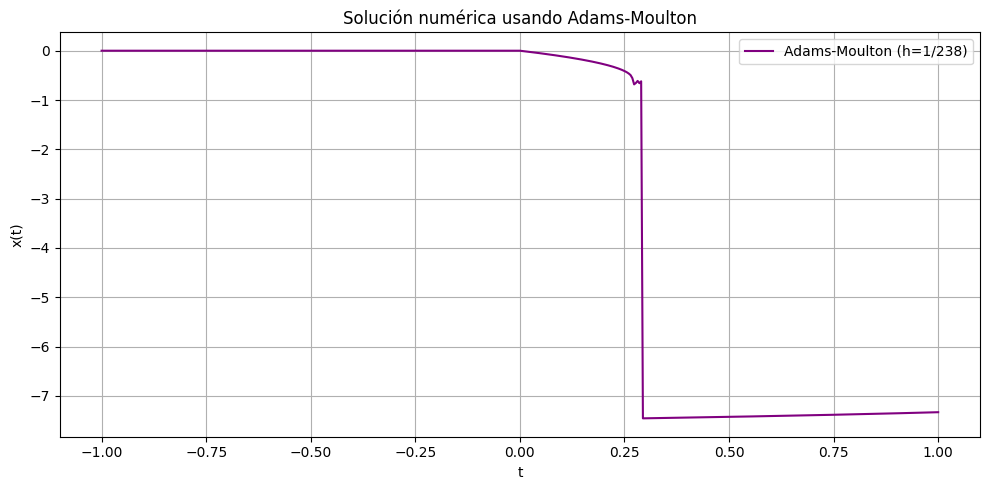

In [5]:
# Solución para la pregunta 21.
import numpy as np
import matplotlib.pyplot as plt

def f(t, x):
    return (t - np.exp(t)) / (x + np.exp(x))

t0 = 0
x0 = 0
h = 1 / 238
n_steps = int((1 - (-1)) / h)

t_vals = np.linspace(-1, 1, n_steps + 1)
x_vals = np.zeros(n_steps + 1)
x_vals[np.abs(t_vals - t0).argmin()] = x0  # colocar x(0) = 0

def rk4_step(t, x, h):
    k1 = f(t, x)
    k2 = f(t + h/2, x + h*k1/2)
    k3 = f(t + h/2, x + h*k2/2)
    k4 = f(t + h, x + h*k3)
    return x + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

mid_idx = np.abs(t_vals - t0).argmin()
x_vals[mid_idx + 1] = rk4_step(t_vals[mid_idx], x_vals[mid_idx], h)

for i in range(mid_idx + 1, n_steps):
    t_k, x_k = t_vals[i], x_vals[i]
    t_k1 = t_vals[i + 1]
    x_pred = x_k + h * f(t_k, x_k)
    x_corr = x_k + (h / 2) * (f(t_k, x_k) + f(t_k1, x_pred))
    x_vals[i + 1] = x_corr

plt.figure(figsize=(10, 5))
plt.plot(t_vals, x_vals, label="Adams-Moulton (h=1/238)", color="purple")
plt.title("Solución numérica usando Adams-Moulton")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 22. Dada la EDO
$
\left\{
\begin{array}{ll}
x'= \frac{2}{t} x(t)+t^2 e^t \\
x(1) = 0  
\end{array}
\right.
 \cdots (2)$

y su solución, resolver con todos los métodos de la pregunta 17 para una partición del intervalo $[1,2]$, elegir $h$ a criterio propio.

Graficar la solución real vs. caada método.

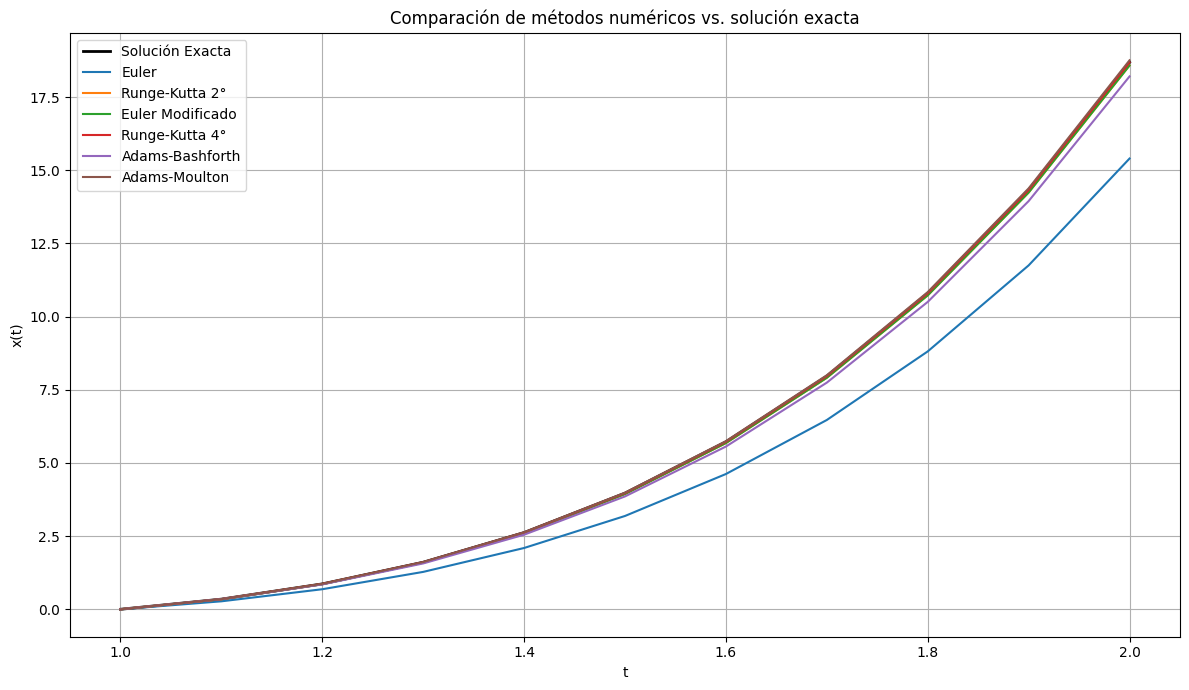

In [6]:
# Respuesta para la pregunta 22.
import numpy as np
import matplotlib.pyplot as plt

# EDO y solución exacta
def f(t, x):
    return (2 / t) * x + t**2 * np.exp(t)

def exact_solution(t):
    return t**2 * (np.exp(t) - np.exp(1))

# Parámetros
t0, tf = 1, 2
h = 0.1
N = int((tf - t0) / h)
t_vals = np.linspace(t0, tf, N + 1)

# Inicialización
x_euler = np.zeros(N + 1)
x_rk2 = np.zeros(N + 1)
x_mod_euler = np.zeros(N + 1)
x_rk4 = np.zeros(N + 1)
x_adams_bashforth = np.zeros(N + 1)
x_adams_moulton = np.zeros(N + 1)
x_exact = exact_solution(t_vals)

x_euler[0] = x_rk2[0] = x_mod_euler[0] = x_rk4[0] = x_adams_bashforth[0] = x_adams_moulton[0] = 0

# Métodos

# Euler
for i in range(N):
    x_euler[i + 1] = x_euler[i] + h * f(t_vals[i], x_euler[i])

# Runge-Kutta 2
for i in range(N):
    k1 = f(t_vals[i], x_rk2[i])
    k2 = f(t_vals[i] + h, x_rk2[i] + h * k1)
    x_rk2[i + 1] = x_rk2[i] + (h / 2) * (k1 + k2)

# Euler Modificado
for i in range(N):
    x_predict = x_mod_euler[i] + h * f(t_vals[i], x_mod_euler[i])
    x_mod_euler[i + 1] = x_mod_euler[i] + (h / 2) * (f(t_vals[i], x_mod_euler[i]) + f(t_vals[i + 1], x_predict))

# Runge-Kutta 4
for i in range(N):
    k1 = f(t_vals[i], x_rk4[i])
    k2 = f(t_vals[i] + h/2, x_rk4[i] + h*k1/2)
    k3 = f(t_vals[i] + h/2, x_rk4[i] + h*k2/2)
    k4 = f(t_vals[i] + h, x_rk4[i] + h*k3)
    x_rk4[i + 1] = x_rk4[i] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# Inicializar primeros dos valores para Adams-Bashforth y Adams-Moulton con RK4
x_adams_bashforth[1] = x_adams_moulton[1] = x_rk4[1]

# Adams-Bashforth (2 pasos)
for i in range(1, N):
    f_n = f(t_vals[i], x_adams_bashforth[i])
    f_n1 = f(t_vals[i - 1], x_adams_bashforth[i - 1])
    x_adams_bashforth[i + 1] = x_adams_bashforth[i] + (h / 2) * (3 * f_n - f_n1)

# Adams-Moulton (2 pasos predictor-corrector)
for i in range(1, N):
    f_n = f(t_vals[i], x_adams_moulton[i])
    f_n1 = f(t_vals[i - 1], x_adams_moulton[i - 1])
    x_pred = x_adams_moulton[i] + (h / 2) * (3 * f_n - f_n1)
    x_adams_moulton[i + 1] = x_adams_moulton[i] + (h / 2) * (f(t_vals[i], x_adams_moulton[i]) + f(t_vals[i + 1], x_pred))

# Gráfica
plt.figure(figsize=(12, 7))
plt.plot(t_vals, x_exact, label="Solución Exacta", color="black", linewidth=2)
plt.plot(t_vals, x_euler, label="Euler")
plt.plot(t_vals, x_rk2, label="Runge-Kutta 2°")
plt.plot(t_vals, x_mod_euler, label="Euler Modificado")
plt.plot(t_vals, x_rk4, label="Runge-Kutta 4°")
plt.plot(t_vals, x_adams_bashforth, label="Adams-Bashforth")
plt.plot(t_vals, x_adams_moulton, label="Adams-Moulton")

plt.title("Comparación de métodos numéricos vs. solución exacta")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 23. Resolver numéricamente el sistema de EDOs en el intervalo $[0,10]$ para $h=0.01$. Usar series de Taylor con cálculo de terceras derivadas.

In [ ]:
# Respuesta para la pregunta 23.

### 24. Resolver usando el método de Runge-Kutta de 4° orden el siguiente sistema:
$
\left\{
\begin{array}{ll}
x'=x^{-2}+log(y)+t^2; \\
y' =e^y-cos(x)+sin(t)*x-(xy)^{-3}
\end{array}
\right.
$

con condición inicial  $
\left\{
\begin{array}{ll}
x(2)=-2;  \\
y(2)= 1
\end{array}
\right.
$

donde $1\leq t \leq2$ y $h=-0.01$.

In [7]:
# Respuesta para la pregunta 24.
import numpy as np

def f(t, x, y):
    return x**(-2) + np.log(y) + t**2

def g(t, x, y):
    return np.exp(y) - np.cos(x) + np.sin(t)*x - (x*y)**(-3)

# Condiciones iniciales
t0 = 2.0
x0 = -2.0
y0 = 1.0
h = -0.01

# Intervalo: de 2 a 1 con paso -0.01
N = int((1 - 2)/h) + 1  # número de pasos

t_values = [t0]
x_values = [x0]
y_values = [y0]

t = t0
x = x0
y = y0

for i in range(N):
    k1 = h * f(t, x, y)
    l1 = h * g(t, x, y)

    k2 = h * f(t + h/2, x + k1/2, y + l1/2)
    l2 = h * g(t + h/2, x + k1/2, y + l1/2)

    k3 = h * f(t + h/2, x + k2/2, y + l2/2)
    l3 = h * g(t + h/2, x + k2/2, y + l2/2)

    k4 = h * f(t + h, x + k3, y + l3)
    l4 = h * g(t + h, x + k3, y + l3)

    x_next = x + (k1 + 2*k2 + 2*k3 + k4)/6
    y_next = y + (l1 + 2*l2 + 2*l3 + l4)/6

    t += h
    x, y = x_next, y_next

    # Guardar valores
    t_values.append(t)
    x_values.append(x)
    y_values.append(y)

# Mostrar resultados finales
print(f"En t = {t_values[-1]:.2f}, x = {x_values[-1]:.5f}, y = {y_values[-1]:.5f}")


En t = 0.99, x = -4.28627, y = 1.03095


### 25. Convertir la siguiente ecuación en un sistema de primer orden y resolver numéricamente.

$$x'''-sin(x'')+e^tx'+2tcos(x)=25$$

$$x(0)=5, x'(0)=3, x''(0)=7$$

Método libre, usar $h=0.1$.

In [8]:
# Respuesta para la pregunta 25.
import numpy as np

def f(t, y):
    y1, y2, y3 = y
    dy1 = y2
    dy2 = y3
    dy3 = np.sin(y3) - np.exp(t)*y2 - 2*t*np.cos(y1) + 25
    return np.array([dy1, dy2, dy3])

# Condiciones iniciales
t0 = 0.0
y0 = np.array([5, 3, 7])
h = 0.1
t_final = 2.0  # Puedes cambiar el intervalo de solución

N = int((t_final - t0) / h)
t_values = [t0]
y_values = [y0]

t = t0
y = y0

for _ in range(N):
    k1 = h * f(t, y)
    k2 = h * f(t + h/2, y + k1/2)
    k3 = h * f(t + h/2, y + k2/2)
    k4 = h * f(t + h, y + k3)

    y = y + (k1 + 2*k2 + 2*k3 + k4) / 6
    t = t + h

    t_values.append(t)
    y_values.append(y)

# Convertir a arrays para mejor manejo
t_values = np.array(t_values)
y_values = np.array(y_values)

# Mostrar resultados finales
print(f"En t = {t_values[-1]:.2f}, x = {y_values[-1,0]:.5f}, x' = {y_values[-1,1]:.5f}, x'' = {y_values[-1,2]:.5f}")


En t = 2.00, x = 31.25931, x' = 7.86723, x'' = -36.70709
